In [1]:
%load_ext autoreload
%autoreload 2
from data_handling import *
import xarray as xr 
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from scipy.stats import gaussian_kde as kde
import sys, os
# from get_ddf import *
sys.path.append('/trace/home/cvwilson/research/PEBSI/shop/plotting/')
from plotting_fxns import * 
import socket
if 'trace' in socket.gethostname():
    base_fp = '/trace/group/rounce/cvwilson/Output/'
    home_fp = '/trace/home/cvwilson/research/'
else:
    base_fp = 'C:/Users/cvw30/Research/Output/'
    home_fp = 'C:/Users/cvw30/Research/'

colors = ['#63c4c7','#fcc02e','#4D559C','#60C252','#BF1F6A',
              '#F77808','#298282','#999999','#FF89B0','#427801']

coord_dict = {'wolverine':'60.5_-148.7',
                'kahiltna':'63.0_-151.2',
                'kennicott':'61.5_-143.1',
                'taku':'58.5_-134.3',
                'lemon_creek':'58.5_-134.3',
                'gulkana':'63.5_-145.6'}
site_dict = {'wolverine':['N','B','EC'],
                'kahiltna':['K53','K17b'], # took out K14k because it's too high --- wind redistribution probably crucial here
                'kennicott':['GTL','GTH','KC31'],
                'lemon_creek':['B','C','D'],
                'taku':['NWB1','TKG3'],
                'gulkana':['AU','B','D'] # 'B','MG1',
                }

In [9]:
fn = 'ddf/{g}{s}_2026_05_06_sar_test_0.nc'
all_mod_albedo = []
all_meas_albedo = []
all_time_albedo = []
best_dict = {}
all_best = {}
only = False # 'good'
snow_only = False
for glacier in site_dict:
    best_dict[glacier] = {}
    all_best[glacier] = {}
    for site in site_dict[glacier]:
        fn_ds = base_fp + fn.format(g=glacier, s=site)
        try:
            ds = xr.open_dataset(fn_ds)
        except:
            continue
    

        albedo_data = Albedo(glacier, site, use='all')
        albedo_data.get_model_albedo(ds, snow_only=snow_only)
        mb_data = MassBalance(glacier, site, use='benchmark')
        mb_data.get_model_mb(ds)

        if len(mb_data.mod) < 2:
            print('insufficient data')
            continue
        elif mb_data.dataset == 'seasonal':
            me_summer, me_winter = mb_data.bias(True)
            if np.abs(me_summer) > 0.8 or np.abs(me_winter) > 0.8:
                print(ds.attrs['glacier'], ds.attrs['site'],'has biased mass balance using kp=',ds.attrs['kp'])
                print('Summer mass balance bias:',me_summer)
                print('Winter mass balance bias:',me_winter)
                print('Albedo bias:',albedo_data.bias())
                print()
                if only == 'bad':
                    for mod, meas, t in zip(albedo_data.mod, albedo_data.meas, albedo_data.time):
                        all_mod_albedo.append(mod)
                        all_meas_albedo.append(meas)
                        all_time_albedo.append(t)
                # mb_data.plot_mb()
            else:
                print(glacier, site, 'is good')
                if only == 'good':
                    for mod, meas, t in zip(albedo_data.mod, albedo_data.meas, albedo_data.time):
                        all_mod_albedo.append(mod)
                        all_meas_albedo.append(meas)
                        all_time_albedo.append(t)
                
        else:
            if np.abs(mb_data.mae()) > 0.8:
                print(ds.attrs['glacier'], ds.attrs['site'],'has biased mass balance using kp=',ds.attrs['kp'])
                print('Annual mass balance bias:',mb_data.mae())
                print('Albedo bias:',albedo_data.bias())
                print()
                # mb_data.plot_mb()
                if only == 'bad':
                    for mod, meas, t in zip(albedo_data.mod, albedo_data.meas, albedo_data.time):
                        all_mod_albedo.append(mod)
                        all_meas_albedo.append(meas)
                        all_time_albedo.append(t)
            else:
                print(glacier, site, 'is good')
                if only == 'good':
                    for mod, meas, t in zip(albedo_data.mod, albedo_data.meas, albedo_data.time):
                        all_mod_albedo.append(mod)
                        all_meas_albedo.append(meas)
                        all_time_albedo.append(t)
                
        if not only:
            for mod, meas, t in zip(albedo_data.mod, albedo_data.meas, albedo_data.time):
                all_mod_albedo.append(mod)
                all_meas_albedo.append(meas)
                all_time_albedo.append(t)
        # plot
        mb_data.plot_mb()
        # albedo_data.plot_timeseries()
        albedo_data.plot_1to1()
        # albedo_data.plot_map('2019-08-20',full=True, savefig=True)

        

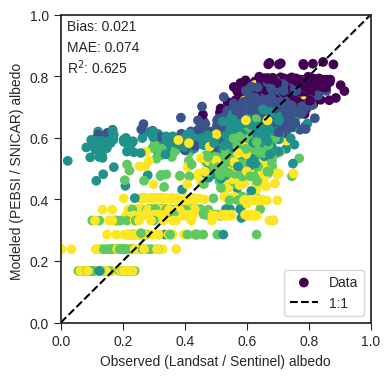

In [6]:
fig, ax = plt.subplots(figsize=(4, 4))
cmap = plt.get_cmap('viridis')
norm = mpl.colors.Normalize(vmin=4, vmax=8)

ax.scatter(all_meas_albedo, all_mod_albedo, label='Data', c=cmap(norm(pd.to_datetime(all_time_albedo).month)))
ax.plot([0,1],[0,1],'k--',label='1:1')

meas = np.array(all_meas_albedo).ravel()
mod = np.array(all_mod_albedo).ravel()
bias = np.nanmean(mod - meas)
mae = np.nanmean(np.abs(meas - mod))
r2 = 1 - np.sum(np.square(meas - mod)) / np.sum(np.square(meas - np.mean(meas)))
ax.text(0.02, 0.95, f'Bias: {bias:.3f}', transform=ax.transAxes)
ax.text(0.02, 0.88, f'MAE: {mae:.3f}', transform=ax.transAxes)
ax.text(0.02, 0.81, f'R$^2$: {r2:.3f}', transform=ax.transAxes)

ax.legend(frameon=True)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.tick_params(length=5)
# ax.set_title('Albedo modeled at Gulkana Glacier')
ax.set_ylabel('Modeled (PEBSI / SNICAR) albedo ')
ax.set_xlabel('Observed (Landsat / Sentinel) albedo')
plt.savefig('/trace/group/rounce/cvwilson/figs/ddf/bad_sites.png', bbox_inches='tight', dpi=300)
plt.show()

In [ ]:

# albedo.plot_1to1()
# for year in range(2019, 2025):
#     albedo.plot_timeseries(years=[year])

Bias between satellite and ground obs -0.04533976172701987
Bias between PEBSI and ground obs -0.07551156199760997
Bias between PEBSI and satellite obs -0.034270022940711464


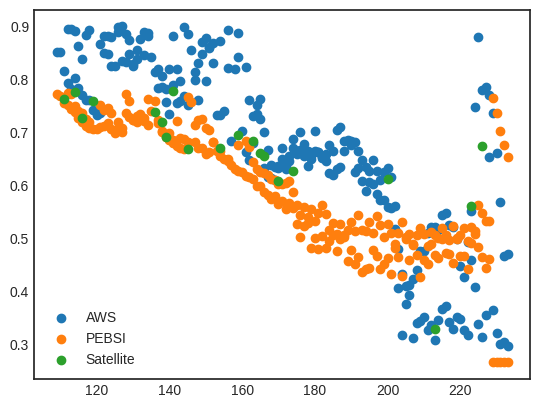

In [ ]:
fn = 'ddf/{g}{s}_2026_05_06_sar_test_0.nc'
glacier, site = 'gulkana','B'
ds = xr.open_dataset(base_fp + fn.format(g=glacier, s=site))

albedo = Albedo(glacier, site, 's2')
albedo.get_model_albedo(ds)

df1 = pd.read_csv('../../climate_data/AWS/Processed/gulkana2024_walbedo.csv', parse_dates=True, index_col=0)
df2 = pd.read_csv('../../climate_data/AWS/Processed/gulkanaB2025_albedo.csv', parse_dates=True, index_col=0)

df1 = df1.loc[df1.index.hour.isin(range(10, 15))]
df2 = df2.loc[df2.index.hour.isin(range(10, 15))]

df2 = df2.resample('1D').mean()
df1 = df1.resample('1D').mean()

df = pd.concat([df1['albedo'], df2['albedo']])
df[df > 0.9] = np.nan
df = df.dropna().to_frame()
df['albedo_rs'] = np.ones(len(df.index)) * np.nan
df['albedo_pebsi'] = np.ones(len(df.index)) * np.nan

for date in df.index:
    if date in pd.to_datetime(albedo.time):
        idx = np.where(date == pd.to_datetime(albedo.time))[0]
        rs_albedo = albedo.data[idx]
        df.loc[date, 'albedo_rs'] = rs_albedo[0]

    df.loc[date, 'albedo_pebsi'] = ds.sel(time=date).albedo.values

print('Bias between satellite and ground obs',np.mean(df['albedo_rs'] - df['albedo']))
print('Bias between PEBSI and ground obs',np.mean(df['albedo_pebsi'] - df['albedo']))
print('Bias between PEBSI and satellite obs', np.mean(df['albedo_pebsi'] - df['albedo_rs']))

plt.scatter(df.index.day_of_year, df['albedo'], label='AWS')
plt.scatter(df.index.day_of_year, df['albedo_pebsi'], label='PEBSI')
plt.scatter(df.index.day_of_year, df['albedo_rs'], label='Satellite')
plt.legend()
plt.show()

In [4]:
glacier, site = 'taku','Taku-1'
ds = xr.open_dataset(base_fp + fn.format(g=glacier, s=site))
ds = ds.sel(time=slice('2016-07-18','2016-07-19'), layer=0).max(dim='time')
print(ds.layerBC.values, ds.layerdust.values, ds.albedo.values)

l = LAPs(site)
print(l.bc_july, l.dust_july)

glacier, site = 'gulkana','D'
ds = xr.open_dataset(base_fp + fn.replace('ratios3','test').format(g=glacier, s=site))

ds = ds.sel(time=slice('2024-08-21','2024-08-22'), layer=0).max(dim='time')
print(ds.layerBC.values, ds.layerdust.values, ds.albedo.values)

484.27198931903547 36.58530385842934 0.511016409058329
6.9 25
15.719383718339696 0.5686955344772515 0.6969761928585518


In [1]:
import numpy as np
from scipy.special import erf

# Inputs from Table 5
dv = 12.5
sigma_table = 10.2 

# The "Missing Link": Convert their linear SD to log-normal sigma
# This makes the math match the Figure.
ln_sigma_g = np.sqrt(np.log(1 + (sigma_table/dv)**2))

bins = [(0.05, 0.5), (0.5, 1.25), (1.25, 2.5), (2.5, 5), (5, 50)]
f = []

for (d1, d2) in bins:
    # Use ln_sigma_g here
    upper = erf(np.log(d2/dv) / (np.sqrt(2) * ln_sigma_g))
    lower = erf(np.log(d1/dv) / (np.sqrt(2) * ln_sigma_g))
    f.append(0.5 * (upper - lower))

# This sum will now be much closer to 1.0 (~0.95)
# Normalize the final result to get exactly 100% for SNICAR
mass_fractions = np.array(f) / np.sum(f)
for m in mass_fractions:
    print(f'{m:.5f}')

0.00000
0.00065
0.01181
0.09003
0.89751


In [ ]:
#######################################################################################